In [16]:
# pip install geodatasets
# pip install geopandas

In [19]:
import numpy as np
import pandas as pd
import geopandas
import geodatasets
from math import sin, cos, asin, acos, radians

from pulp import *
import matplotlib.pyplot as plt
plt.style.use('ggplot')

C:\Users\siraj\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [20]:
# Load dataframe
df = pd.read_csv(
    './in (1).csv', 
    usecols = ['city', 'lat', 'lng', 'population', 'capital', 'admin_name'])
df

,city,lat,lng,admin_name,capital,population
0,Delhi,28.6600,77.2300,Delhi,admin,29617000.0
1,Mumbai,18.9667,72.8333,Mahārāshtra,admin,23355000.0
2,Kolkāta,22.5411,88.3378,West Bengal,admin,17560000.0
3,Bangalore,12.9699,77.5980,Karnātaka,admin,13707000.0
4,Chennai,13.0825,80.2750,Tamil Nādu,admin,11324000.0
...,...,...,...,...,...,...
401,Abu,24.5925,72.7083,Rājasthān,NaN,22943.0
402,Curchorem,15.2500,74.1000,Goa,NaN,22730.0
403,Kavaratti,10.5626,72.6369,Lakshadweep,admin,10688.0
404,Panchkula,30.6915,76.8537,Haryāna,minor,NaN


In [21]:
RANDOM_STATE = 2          # For reproducibility
FRACTION_CUSTOMERS = 0.3  # Fraction of cities we want to keep as customers
FRACTION_WAREHOUSES = 0.8 # Fraction of cities we want to keep as warehouse locations
FRACTION_DEMAND = 0.02    # Fraction of citizens of a city that may order a product  

# List of the 31 regions of India
REGION_LIST = [
    'Delhi', 'Mahārāshtra', 'West Bengal', 'Karnātaka', 'Tamil Nādu', 
    'Telangana', 'Uttar Pradesh','Rājasthān', 'Madhya Pradesh', 'Bihār',
    'Jammu and Kashmīr', 'Jharkhand', 'Chandīgarh', 'Chhattīsgarh',
    'Assam', 'Odisha', 'Kerala', 'Uttarakhand', 'Tripura', 'Mizoram',
    'Manipur','Puducherry','Himāchal Pradesh','Gujarāt','Haryāna',
    'Meghālaya','Andaman and Nicobar Islands','Sikkim','Nāgāland',
    'Arunāchal Pradesh','Goa','Lakshadweep']

# Demand is composed of: 
#   1. A fraction of the population
#   2. An error term of uniform distribution
# Note: demand is approximated to the closest int 
# as its physical meaning denies decimals
df['demand'] = np.floor(
    FRACTION_DEMAND * df.population + np.random.uniform(-10, 10, size=(df.shape[0],)))

# Create the warehouses dataframe:
#   1. Filter the 31 regions of India
#   2. Filter capitals as candidate warehouse locations
#   3. Sample a fraction of the original cities
facility_df = df.\
                loc[df.admin_name.isin(REGION_LIST)].\
                loc[df.capital.isin(['admin', 'minor'])].\
                sample(frac=FRACTION_WAREHOUSES, random_state=RANDOM_STATE, ignore_index=True)

# Create the customers dataframe:
#   1. Filter the 31 regions of India
#   2. Sample a fraction of the original cities
customer_df = df.\
                loc[df.admin_name.isin(REGION_LIST)].\
                sample(frac=FRACTION_CUSTOMERS, random_state=RANDOM_STATE, ignore_index=True)

# Customers IDs list
customer_df['customer_id'] = range(1, 1 + customer_df.shape[0])

In [22]:
facility_df

,city,lat,lng,admin_name,capital,population,demand
0,Rānchi,23.3556,85.3347,Jharkhand,admin,1073440.0,21465.0
1,Chandīgarh,30.7353,76.7911,Chandīgarh,admin,1026459.0,20536.0
2,Gangtok,27.3300,88.6200,Sikkim,admin,100286.0,2010.0
3,Itānagar,27.1000,93.6200,Arunāchal Pradesh,admin,59490.0,1191.0
4,Dispur,26.1500,91.7700,Assam,admin,957352.0,19151.0
5,Bhopāl,23.2500,77.4167,Madhya Pradesh,admin,1883381.0,37672.0
6,Damān,20.4170,72.8500,Gujarāt,admin,39737.0,798.0
7,Delhi,28.6600,77.2300,Delhi,admin,29617000.0,592333.0
8,Kavaratti,10.5626,72.6369,Lakshadweep,admin,10688.0,217.0
9,Shimla,31.1033,77.1722,Himāchal Pradesh,admin,206575.0,4138.0


In [23]:
customer_df

,city,lat,lng,admin_name,capital,population,demand,customer_id
0,New Delhi,28.7000,77.2000,Delhi,primary,142004.0,2844.0,1
1,Fatehpur,25.8804,80.8000,Uttar Pradesh,NaN,166480.0,3329.0,2
2,Ahmedabad,23.0300,72.5800,Gujarāt,minor,7410000.0,148194.0,3
3,Tiruppūr,11.1075,77.3398,Tamil Nādu,NaN,650000.0,12998.0,4
4,Sīkar,27.6119,75.1397,Rājasthān,NaN,400000.0,7994.0,5
...,...,...,...,...,...,...,...,...
91,Puri,19.8000,85.8167,Odisha,NaN,201026.0,4011.0,92
92,Chittaurgarh,24.8894,74.6239,Rājasthān,NaN,116406.0,2321.0,93
93,Bhātpāra,22.8667,88.4167,West Bengal,NaN,386019.0,7710.0,94
94,Nāsik,20.0000,73.7833,Mahārāshtra,NaN,1486053.0,29720.0,95


In [24]:
def add_geocoordinates(df, lat='lat', lng='lng'):
    '''
    Add column "geometry" with <shapely.geometry.point.Point> objects 
        built from latitude and longitude values in the input dataframe
    
    Args:
        - df: input dataframe
        - lat: name of the column containing the latitude (default: lat)
        - lng: name of the column containing the longitude (default: lng)
    Out:
        - df: same dataframe enriched with a geo-coordinate column
    '''
    assert pd.Series([lat, lng]).isin(df.columns).all(),\
        f'Cannot find columns "{lat}" and/or "{lng}" in the input dataframe.'
    return geopandas.GeoDataFrame(
        df, geometry=geopandas.points_from_xy(df.lng, df.lat))


customer_df = add_geocoordinates(customer_df)
facility_df = add_geocoordinates(facility_df)

In [25]:
customer_df

,city,lat,lng,admin_name,capital,population,demand,customer_id,geometry
0,New Delhi,28.7000,77.2000,Delhi,primary,142004.0,2844.0,1,POINT (77.2 28.7)
1,Fatehpur,25.8804,80.8000,Uttar Pradesh,NaN,166480.0,3329.0,2,POINT (80.8 25.8804)
2,Ahmedabad,23.0300,72.5800,Gujarāt,minor,7410000.0,148194.0,3,POINT (72.58 23.03)
3,Tiruppūr,11.1075,77.3398,Tamil Nādu,NaN,650000.0,12998.0,4,POINT (77.3398 11.1075)
4,Sīkar,27.6119,75.1397,Rājasthān,NaN,400000.0,7994.0,5,POINT (75.1397 27.6119)
...,...,...,...,...,...,...,...,...,...
91,Puri,19.8000,85.8167,Odisha,NaN,201026.0,4011.0,92,POINT (85.8167 19.8)
92,Chittaurgarh,24.8894,74.6239,Rājasthān,NaN,116406.0,2321.0,93,POINT (74.6239 24.8894)
93,Bhātpāra,22.8667,88.4167,West Bengal,NaN,386019.0,7710.0,94,POINT (88.4167 22.8667)
94,Nāsik,20.0000,73.7833,Mahārāshtra,NaN,1486053.0,29720.0,95,POINT (73.7833 20)


In [26]:
facility_df

,city,lat,lng,admin_name,capital,population,demand,geometry
0,Rānchi,23.3556,85.3347,Jharkhand,admin,1073440.0,21465.0,POINT (85.3347 23.3556)
1,Chandīgarh,30.7353,76.7911,Chandīgarh,admin,1026459.0,20536.0,POINT (76.7911 30.7353)
2,Gangtok,27.3300,88.6200,Sikkim,admin,100286.0,2010.0,POINT (88.62 27.33)
3,Itānagar,27.1000,93.6200,Arunāchal Pradesh,admin,59490.0,1191.0,POINT (93.62 27.1)
4,Dispur,26.1500,91.7700,Assam,admin,957352.0,19151.0,POINT (91.77 26.15)
5,Bhopāl,23.2500,77.4167,Madhya Pradesh,admin,1883381.0,37672.0,POINT (77.4167 23.25)
6,Damān,20.4170,72.8500,Gujarāt,admin,39737.0,798.0,POINT (72.85 20.417)
7,Delhi,28.6600,77.2300,Delhi,admin,29617000.0,592333.0,POINT (77.23 28.66)
8,Kavaratti,10.5626,72.6369,Lakshadweep,admin,10688.0,217.0,POINT (72.6369 10.5626)
9,Shimla,31.1033,77.1722,Himāchal Pradesh,admin,206575.0,4138.0,POINT (77.1722 31.1033)


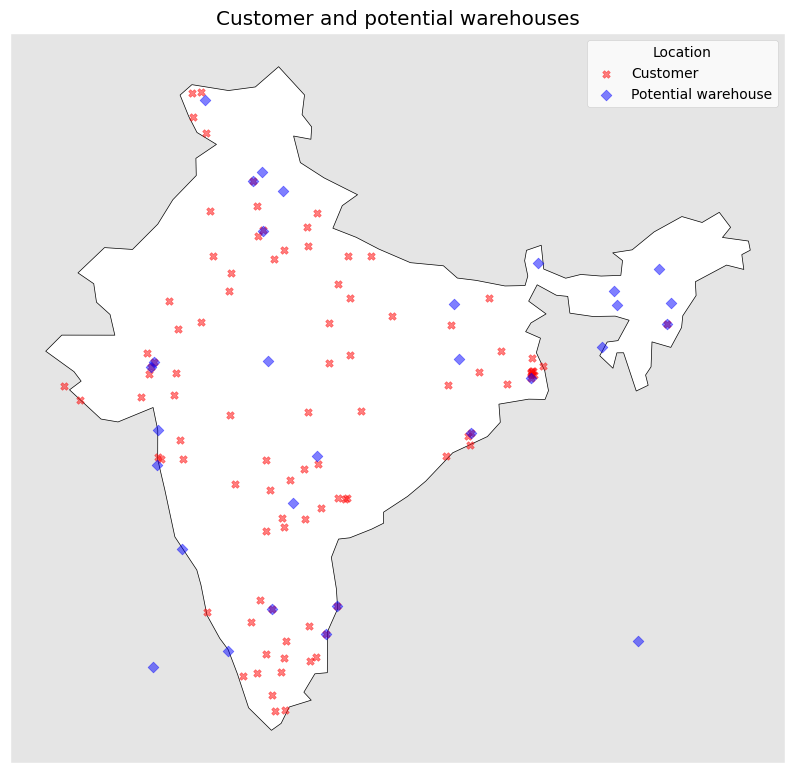

In [37]:
# Prepare country plot
world = geopandas.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# Extract and plot the shape of India
india = world[world["ADMIN"] == "India"]
ax = india.plot(color='white', edgecolor='black', figsize=(10, 10))

# Plot customers as points
customer_df.\
    plot(ax=ax, marker='X', color='red', markersize=30, alpha=0.5, label='Customer')

# Plot potential facility locations as points
facility_df.\
    plot(ax=ax, marker='D', color='blue', markersize=30, alpha=0.5, label='Potential warehouse')

# Add legend
plt.legend(facecolor='white', title='Location')

# Add title
plt.title('Customer and potential warehouses')

# Remove ticks from axis
plt.xticks([])
plt.yticks([])

# Show plot
plt.show()


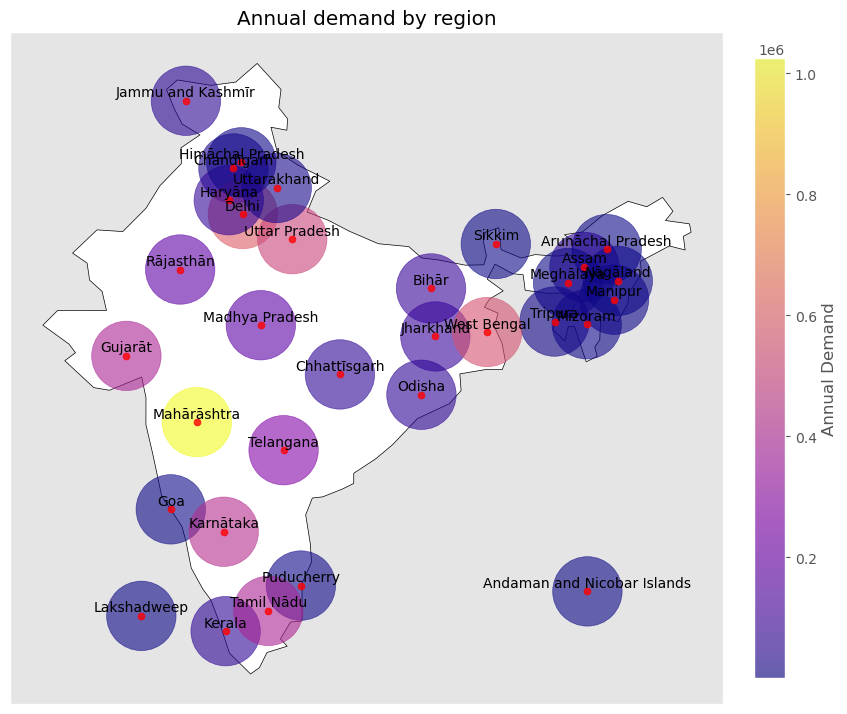

In [38]:
# Prepare region dataframe:
#   1. Filter the 31 regions of India
#   2. Group by region
#   3. Calculate:
#      - Mean regional latitude
#      - Mean regional longitude
#      - Sum of regional demand
region_df = df.\
             loc[df.admin_name.isin(REGION_LIST)].\
             groupby(['admin_name']).\
             agg({'lat': 'mean', 'lng': 'mean', 'demand': 'sum'}).\
             reset_index()

# Add geo-coordinates
region_df = add_geocoordinates(region_df)

# Plot the shape of India
ax = india.plot(color='white', edgecolor='black', figsize=(10, 10))

# Plot region area colored based on demand
region_df.\
    plot(ax=ax, column='demand', marker='o', c='demand', cmap='plasma', markersize=2500, alpha=0.6)

# Add region 'center' as red dots
region_df.\
    plot(ax=ax, marker='o', c='red', markersize=25, alpha=0.8, label='Customer location')

# Add region name above the center
for i, row in region_df.iterrows():
    plt.annotate(
        row.admin_name, xy=(row.lng, row.lat+0.2), horizontalalignment='center')

# Add color bar with demand scale
plt.colorbar(ax.get_children()[1], ax=ax, label='Annual Demand', fraction=0.04, pad=0.04) 

# Add title
plt.title('Annual demand by region')

# Remove ticks from axis
plt.xticks([])
plt.yticks([])

# Show plot
plt.show()

In [39]:
region_df

,admin_name,lat,lng,demand,geometry
0,Andaman and Nicobar Islands,11.666700,92.750000,2546.0,POINT (92.75 11.6667)
1,Arunāchal Pradesh,27.100000,93.620000,1191.0,POINT (93.62 27.1)
2,Assam,26.293457,92.616200,47445.0,POINT (92.6162 26.29346)
3,Bihār,25.326650,85.699370,78634.0,POINT (85.69937 25.32665)
4,Chandīgarh,30.735300,76.791100,20536.0,POINT (76.7911 30.7353)
5,Chhattīsgarh,21.448650,81.590925,54132.0,POINT (81.59092 21.44865)
6,Delhi,28.680000,77.215000,595177.0,POINT (77.215 28.68)
7,Goa,15.365000,73.965000,1246.0,POINT (73.965 15.365)
8,Gujarāt,22.284570,71.963590,385905.0,POINT (71.96359 22.28457)
9,Haryāna,29.304782,76.580091,71365.0,POINT (76.58009 29.30478)


In [40]:
# Dictionary of cutomer id (id) and demand (value)
demand_dict = { customer : customer_df['demand'][i] for i, customer in enumerate(customer_df['customer_id']) }
demand_dict

{1: 2844.0,
 2: 3329.0,
 3: 148194.0,
 4: 12998.0,
 5: 7994.0,
 6: 3133.0,
 7: 4150.0,
 8: 5928.0,
 9: 4137.0,
 10: 10034.0,
 11: 1053.0,
 12: 12484.0,
 13: 7994.0,
 14: 3639.0,
 15: 1062.0,
 16: 25352.0,
 17: 8722.0,
 18: 2994.0,
 19: 3948.0,
 20: 5387.0,
 21: 1602.0,
 22: 3229.0,
 23: 2238.0,
 24: 48119.0,
 25: 274130.0,
 26: 5371.0,
 27: 1544.0,
 28: 2515.0,
 29: 25236.0,
 30: 2423.0,
 31: 12477.0,
 32: 691.0,
 33: 7538.0,
 34: 661.0,
 35: 1105.0,
 36: 673.0,
 37: 22631.0,
 38: 4599.0,
 39: 795.0,
 40: 61464.0,
 41: 13865.0,
 42: 2790.0,
 43: 4693.0,
 44: 6503.0,
 45: 1081.0,
 46: 840.0,
 47: 7401.0,
 48: 3297.0,
 49: 1609.0,
 50: 12513.0,
 51: 3635.0,
 52: 49941.0,
 53: 586.0,
 54: 9490.0,
 55: 5998.0,
 56: 10851.0,
 57: 2769.0,
 58: 11094.0,
 59: 20536.0,
 60: 54019.0,
 61: 3639.0,
 62: 3235.0,
 63: 6610.0,
 64: 16761.0,
 65: 5113.0,
 66: 4553.0,
 67: 9014.0,
 68: 3921.0,
 69: 351193.0,
 70: 3640.0,
 71: 1590.0,
 72: 674.0,
 73: 4449.0,
 74: 3664.0,
 75: 31152.0,
 76: 2134.0,
 77:

In [41]:
# Assumptions: 
#    1. Each warehouse has an annual cost of 1,00,00,000 inr: rent, electricity, ...
#    2. Each warehouse can meet 3 times the regional average annual demand
COST_PER_WAREHOUSE = 10_000_000
SUPPLY_FACTOR_PER_WAREHOUSE = 3
SUPPLY_PER_WAREHOUSE = region_df.demand.mean() * SUPPLY_FACTOR_PER_WAREHOUSE

# Warehouses list
facility_df['warehouse_id'] = ['Warehouse ' + str(i) for i in range(1, 1 + facility_df.shape[0])]

# Dictionary of warehouse id (id) and max supply (value)
annual_supply_dict = { warehouse : SUPPLY_PER_WAREHOUSE for warehouse in facility_df['warehouse_id'] }

# Dictionary of warehouse id (id) and fixed costs (value)
annual_cost_dict = { warehouse : COST_PER_WAREHOUSE for warehouse in facility_df['warehouse_id'] }

In [42]:
annual_supply_dict

{'Warehouse 1': 474417.0,
 'Warehouse 2': 474417.0,
 'Warehouse 3': 474417.0,
 'Warehouse 4': 474417.0,
 'Warehouse 5': 474417.0,
 'Warehouse 6': 474417.0,
 'Warehouse 7': 474417.0,
 'Warehouse 8': 474417.0,
 'Warehouse 9': 474417.0,
 'Warehouse 10': 474417.0,
 'Warehouse 11': 474417.0,
 'Warehouse 12': 474417.0,
 'Warehouse 13': 474417.0,
 'Warehouse 14': 474417.0,
 'Warehouse 15': 474417.0,
 'Warehouse 16': 474417.0,
 'Warehouse 17': 474417.0,
 'Warehouse 18': 474417.0,
 'Warehouse 19': 474417.0,
 'Warehouse 20': 474417.0,
 'Warehouse 21': 474417.0,
 'Warehouse 22': 474417.0,
 'Warehouse 23': 474417.0,
 'Warehouse 24': 474417.0,
 'Warehouse 25': 474417.0,
 'Warehouse 26': 474417.0,
 'Warehouse 27': 474417.0,
 'Warehouse 28': 474417.0,
 'Warehouse 29': 474417.0,
 'Warehouse 30': 474417.0}

In [43]:
annual_cost_dict

{'Warehouse 1': 10000000,
 'Warehouse 2': 10000000,
 'Warehouse 3': 10000000,
 'Warehouse 4': 10000000,
 'Warehouse 5': 10000000,
 'Warehouse 6': 10000000,
 'Warehouse 7': 10000000,
 'Warehouse 8': 10000000,
 'Warehouse 9': 10000000,
 'Warehouse 10': 10000000,
 'Warehouse 11': 10000000,
 'Warehouse 12': 10000000,
 'Warehouse 13': 10000000,
 'Warehouse 14': 10000000,
 'Warehouse 15': 10000000,
 'Warehouse 16': 10000000,
 'Warehouse 17': 10000000,
 'Warehouse 18': 10000000,
 'Warehouse 19': 10000000,
 'Warehouse 20': 10000000,
 'Warehouse 21': 10000000,
 'Warehouse 22': 10000000,
 'Warehouse 23': 10000000,
 'Warehouse 24': 10000000,
 'Warehouse 25': 10000000,
 'Warehouse 26': 10000000,
 'Warehouse 27': 10000000,
 'Warehouse 28': 10000000,
 'Warehouse 29': 10000000,
 'Warehouse 30': 10000000}

In [44]:
facility_df.head()

,city,lat,lng,admin_name,capital,population,demand,geometry,warehouse_id
0,Rānchi,23.3556,85.3347,Jharkhand,admin,1073440.0,21465.0,POINT (85.3347 23.3556),Warehouse 1
1,Chandīgarh,30.7353,76.7911,Chandīgarh,admin,1026459.0,20536.0,POINT (76.7911 30.7353),Warehouse 2
2,Gangtok,27.3300,88.6200,Sikkim,admin,100286.0,2010.0,POINT (88.62 27.33),Warehouse 3
3,Itānagar,27.1000,93.6200,Arunāchal Pradesh,admin,59490.0,1191.0,POINT (93.62 27.1),Warehouse 4
4,Dispur,26.1500,91.7700,Assam,admin,957352.0,19151.0,POINT (91.77 26.15),Warehouse 5


In [45]:
def haversine_distance(lat1, lon1, lat2, lon2):
    '''
    Calculate distance between two locations given latitude and longitude.

    Args:
       - lat1: latitude of the first location
       - lon1: longitude of the first location
       - lat2: latitude of the second location
       - lon2: longitude of the second location
    Out:
       - Distance in Km
    
    Ref: 
       - https://en.wikipedia.org/wiki/Haversine_formula
    '''
    return 6371.01 *\
            acos(sin(radians(lat1))*sin(radians(lat2)) +\
            cos(radians(lat1))*cos(radians(lat2))*cos(radians(lon1)-radians(lon2)))

def traveling_cost(distance_in_km):
    '''
    Return traveling cost in euros given a distance in Km.

    Args:
      - distance_in_km: travel distance in Km
    Out:
      - cost of the trip in euros
    '''
    return 14.6 * distance_in_km     # 0.154 Litre per km diesel and 95rs per litre diesel

In [46]:
haversine_distance(34.0911,74.8061, 13.0825,80.2750)   # distance between srinagar and chennai

2400.4584127561934

In [47]:
# Dict to store the distances between all warehouses and customers
transport_costs_dict = {}

# For each warehouse location
for i in range(0, facility_df.shape[0]):
    
    # Dict to store the distances between the i-th warehouse and all customers
    warehouse_transport_costs_dict = {}
    
    # For each customer location
    for j in range(0, customer_df.shape[0]):
        
        # Distance in Km between warehouse i and customer j
        d = 0 if facility_df.city[i]==customer_df.city[j] else haversine_distance(
            facility_df.lat[i], facility_df.lng[i], customer_df.lat[j], customer_df.lng[j])
        
        # Update costs for warehouse i
        warehouse_transport_costs_dict.update({customer_df.customer_id[j]: traveling_cost(d)})
    
    # Final dictionary with all costs for all warehouses
    transport_costs_dict.update({facility_df.warehouse_id[i]: warehouse_transport_costs_dict})

In [48]:
transport_costs_dict

{'Warehouse 1': {1: 14692.912364630634,
  2: 7847.112575030104,
  3: 19034.37201331406,
  4: 23415.41013043177,
  5: 16452.682813956893,
  6: 4503.543972429536,
  7: 3409.6962933822565,
  8: 12770.264187801724,
  9: 24014.747975766863,
  10: 21363.20148456533,
  11: 11352.370330374777,
  12: 23429.206046492225,
  13: 20624.133845875855,
  14: 17976.209087094678,
  15: 12195.998753658054,
  16: 8061.473405189441,
  17: 26172.82048412764,
  18: 2657.31809331524,
  19: 14684.109650767308,
  20: 23807.650082845663,
  21: 13383.166225261966,
  22: 11872.371078603896,
  23: 16412.40890707442,
  24: 10048.780225759281,
  25: 20643.93014758306,
  26: 12985.482933851034,
  27: 23053.594363365242,
  28: 4517.3191906379425,
  29: 19896.09537104594,
  30: 4552.2613945284065,
  31: 13894.393205555525,
  32: 12048.621290336483,
  33: 4661.998343361495,
  34: 6705.294906093903,
  35: 17889.886891800114,
  36: 25471.03293170961,
  37: 12907.566963391235,
  38: 18156.358416987077,
  39: 18586.698979198

# FORMULATING THE LP PROBLEM

In [49]:
# Define linear problem
lp_problem = LpProblem('CFLP', LpMinimize)


# Variable: y_j (constraint: it is binary)
created_facility = LpVariable.dicts(
    'Create_facility', facility_df['warehouse_id'], 0, 1, LpBinary)

# Variable: x_ij
served_customer = LpVariable.dicts(
    'Link', [(i,j) for i in customer_df['customer_id'] for j in facility_df['warehouse_id']], 0)


# Objective function 
objective = lpSum(annual_cost_dict[j]*created_facility[j] for j in facility_df['warehouse_id']) +\
            lpSum(transport_costs_dict[j][i]*served_customer[(i,j)] \
                  for j in facility_df['warehouse_id'] for i in customer_df['customer_id'])

lp_problem += objective

# Costraint: the demand must be met
for i in customer_df['customer_id']:
    lp_problem += lpSum(served_customer[(i,j)] for j in facility_df['warehouse_id']) == demand_dict[i]

# Constraint: a warehouse cannot deliver more than its capacity limit
for j in facility_df['warehouse_id']:
    lp_problem += lpSum(served_customer[(i,j)] for i in customer_df['customer_id']) <= annual_supply_dict[j] * created_facility[j]

# Constraint: a warehouse cannot give a customer more than its demand
for i in customer_df['customer_id']:
    for j in facility_df['warehouse_id']:
        lp_problem += served_customer[(i,j)] <= demand_dict[i] * created_facility[j]

In [52]:
lp_problem.solve(PULP_CBC_CMD(msg=True))
print('Solution: ', LpStatus[lp_problem.status])
print(value(lp_problem.objective))

Solution:  Optimal
2134163822.169511


In [53]:
value(lp_problem.objective)

2134163822.169511

In [54]:
created_facility['Warehouse 1'].varValue

1.0

In [55]:
for s in created_facility.values():
    print(s.value())

1.0
1.0
0.0
0.0
0.0
1.0
1.0
1.0
0.0
0.0
1.0
1.0
0.0
0.0
0.0
1.0
0.0
1.0
1.0
1.0
1.0
0.0
1.0
1.0
0.0
1.0
1.0
0.0
1.0
1.0


In [56]:
# List of the values assumed by the binary variable created_facility
facility_values = [i.varValue for i in created_facility.values()]

# Count of each distinct value of the list
[[i, facility_values.count(i)] for i in set(facility_values)]

[[0.0, 12], [1.0, 18]]

In [57]:
# It is sufficient to build just 18 of the initially budgeted 30 sites. The 60.00% (18 / 30) of all potential warehouses is enough to meet the demand under the given constraints.

# We can save the decision variable in the initial data frame and observe the chosen locations:

In [58]:
# Create dataframe column to store whether to build the warehouse or not 
facility_df['build_warehouse'] = ''

# Assign Yes/No to the dataframe column based on the optimization binary variable
for i in facility_df['warehouse_id']:
    if created_facility[i].varValue == 1:
        print('Build site at: ', i)
        facility_df.loc[facility_df['warehouse_id'] == i, 'build_warehouse'] = 'Yes'
    else:
        facility_df.loc[facility_df['warehouse_id'] == i, 'build_warehouse'] = 'No'

Build site at:  Warehouse 1
Build site at:  Warehouse 2
Build site at:  Warehouse 6
Build site at:  Warehouse 7
Build site at:  Warehouse 8
Build site at:  Warehouse 11
Build site at:  Warehouse 12
Build site at:  Warehouse 16
Build site at:  Warehouse 18
Build site at:  Warehouse 19
Build site at:  Warehouse 20
Build site at:  Warehouse 21
Build site at:  Warehouse 23
Build site at:  Warehouse 24
Build site at:  Warehouse 26
Build site at:  Warehouse 27
Build site at:  Warehouse 29
Build site at:  Warehouse 30


In [59]:
facility_df

,city,lat,lng,admin_name,capital,population,demand,geometry,warehouse_id,build_warehouse
0,Rānchi,23.3556,85.3347,Jharkhand,admin,1073440.0,21465.0,POINT (85.3347 23.3556),Warehouse 1,Yes
1,Chandīgarh,30.7353,76.7911,Chandīgarh,admin,1026459.0,20536.0,POINT (76.7911 30.7353),Warehouse 2,Yes
2,Gangtok,27.3300,88.6200,Sikkim,admin,100286.0,2010.0,POINT (88.62 27.33),Warehouse 3,No
3,Itānagar,27.1000,93.6200,Arunāchal Pradesh,admin,59490.0,1191.0,POINT (93.62 27.1),Warehouse 4,No
4,Dispur,26.1500,91.7700,Assam,admin,957352.0,19151.0,POINT (91.77 26.15),Warehouse 5,No
5,Bhopāl,23.2500,77.4167,Madhya Pradesh,admin,1883381.0,37672.0,POINT (77.4167 23.25),Warehouse 6,Yes
6,Damān,20.4170,72.8500,Gujarāt,admin,39737.0,798.0,POINT (72.85 20.417),Warehouse 7,Yes
7,Delhi,28.6600,77.2300,Delhi,admin,29617000.0,592333.0,POINT (77.23 28.66),Warehouse 8,Yes
8,Kavaratti,10.5626,72.6369,Lakshadweep,admin,10688.0,217.0,POINT (72.6369 10.5626),Warehouse 9,No
9,Shimla,31.1033,77.1722,Himāchal Pradesh,admin,206575.0,4138.0,POINT (77.1722 31.1033),Warehouse 10,No


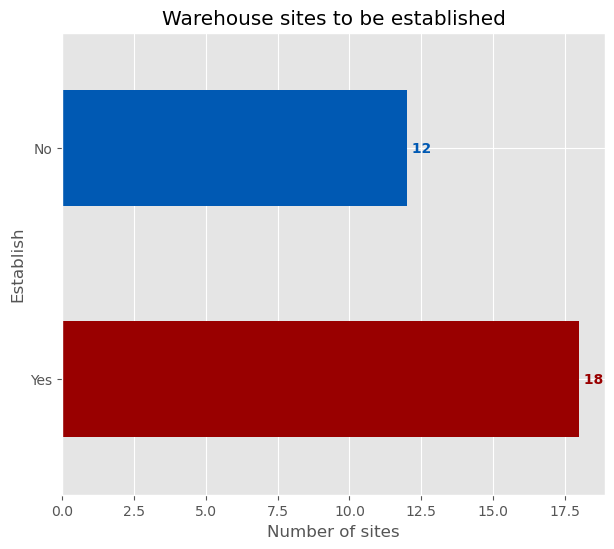

In [60]:
colors = ['#990000', '#0059b3']

facility_df.build_warehouse.value_counts().plot.barh(
  title='Warehouse sites to be established', xlabel='Number of sites', color=colors, ylabel='Establish', figsize=(7,6)) 

for i, v in enumerate(facility_df.build_warehouse.value_counts()):
    plt.text(v, i, ' '+str(round(v,3)), color=colors[i], va='center', fontweight='bold')

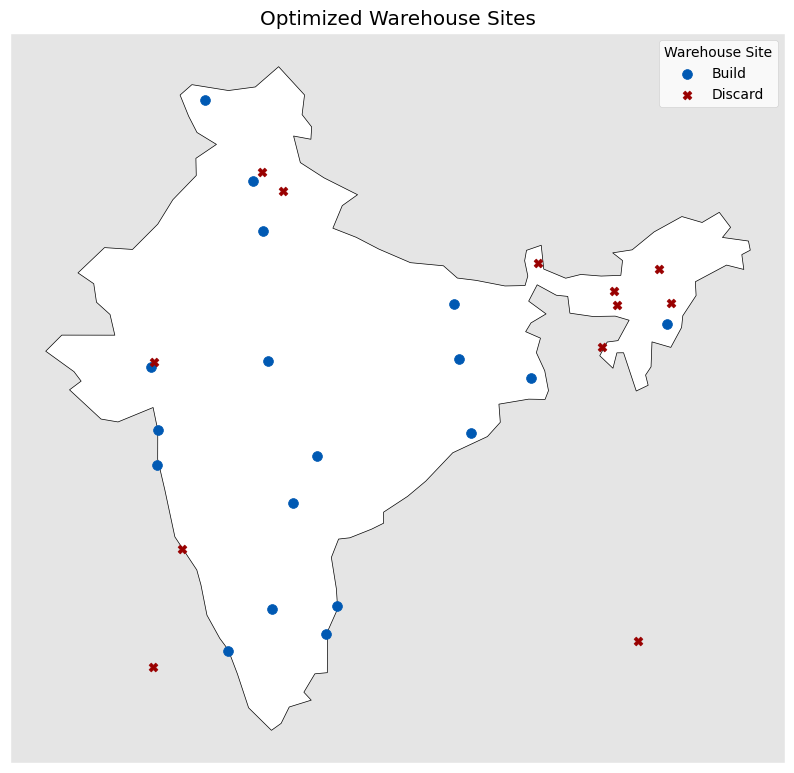

In [61]:
# Plot the shape of India
ax = india.plot(color='white', edgecolor='black', figsize=(10, 10))

# Plot sites to establish
facility_df.\
    loc[facility_df.build_warehouse =='Yes'].\
    plot(ax=ax, marker='o', c='#0059b3', markersize=50, label='Build')

# Plot sites to discard
facility_df.\
    loc[facility_df.build_warehouse =='No'].\
    plot(ax=ax, marker='X', c='#990000', markersize=40, label='Discard')

# Add title
plt.title('Optimized Warehouse Sites')

# Add legend
plt.legend(title='Warehouse Site', facecolor='white')

# Remove ticks from axis
plt.xticks([])
plt.yticks([])

# Show plot
plt.show()

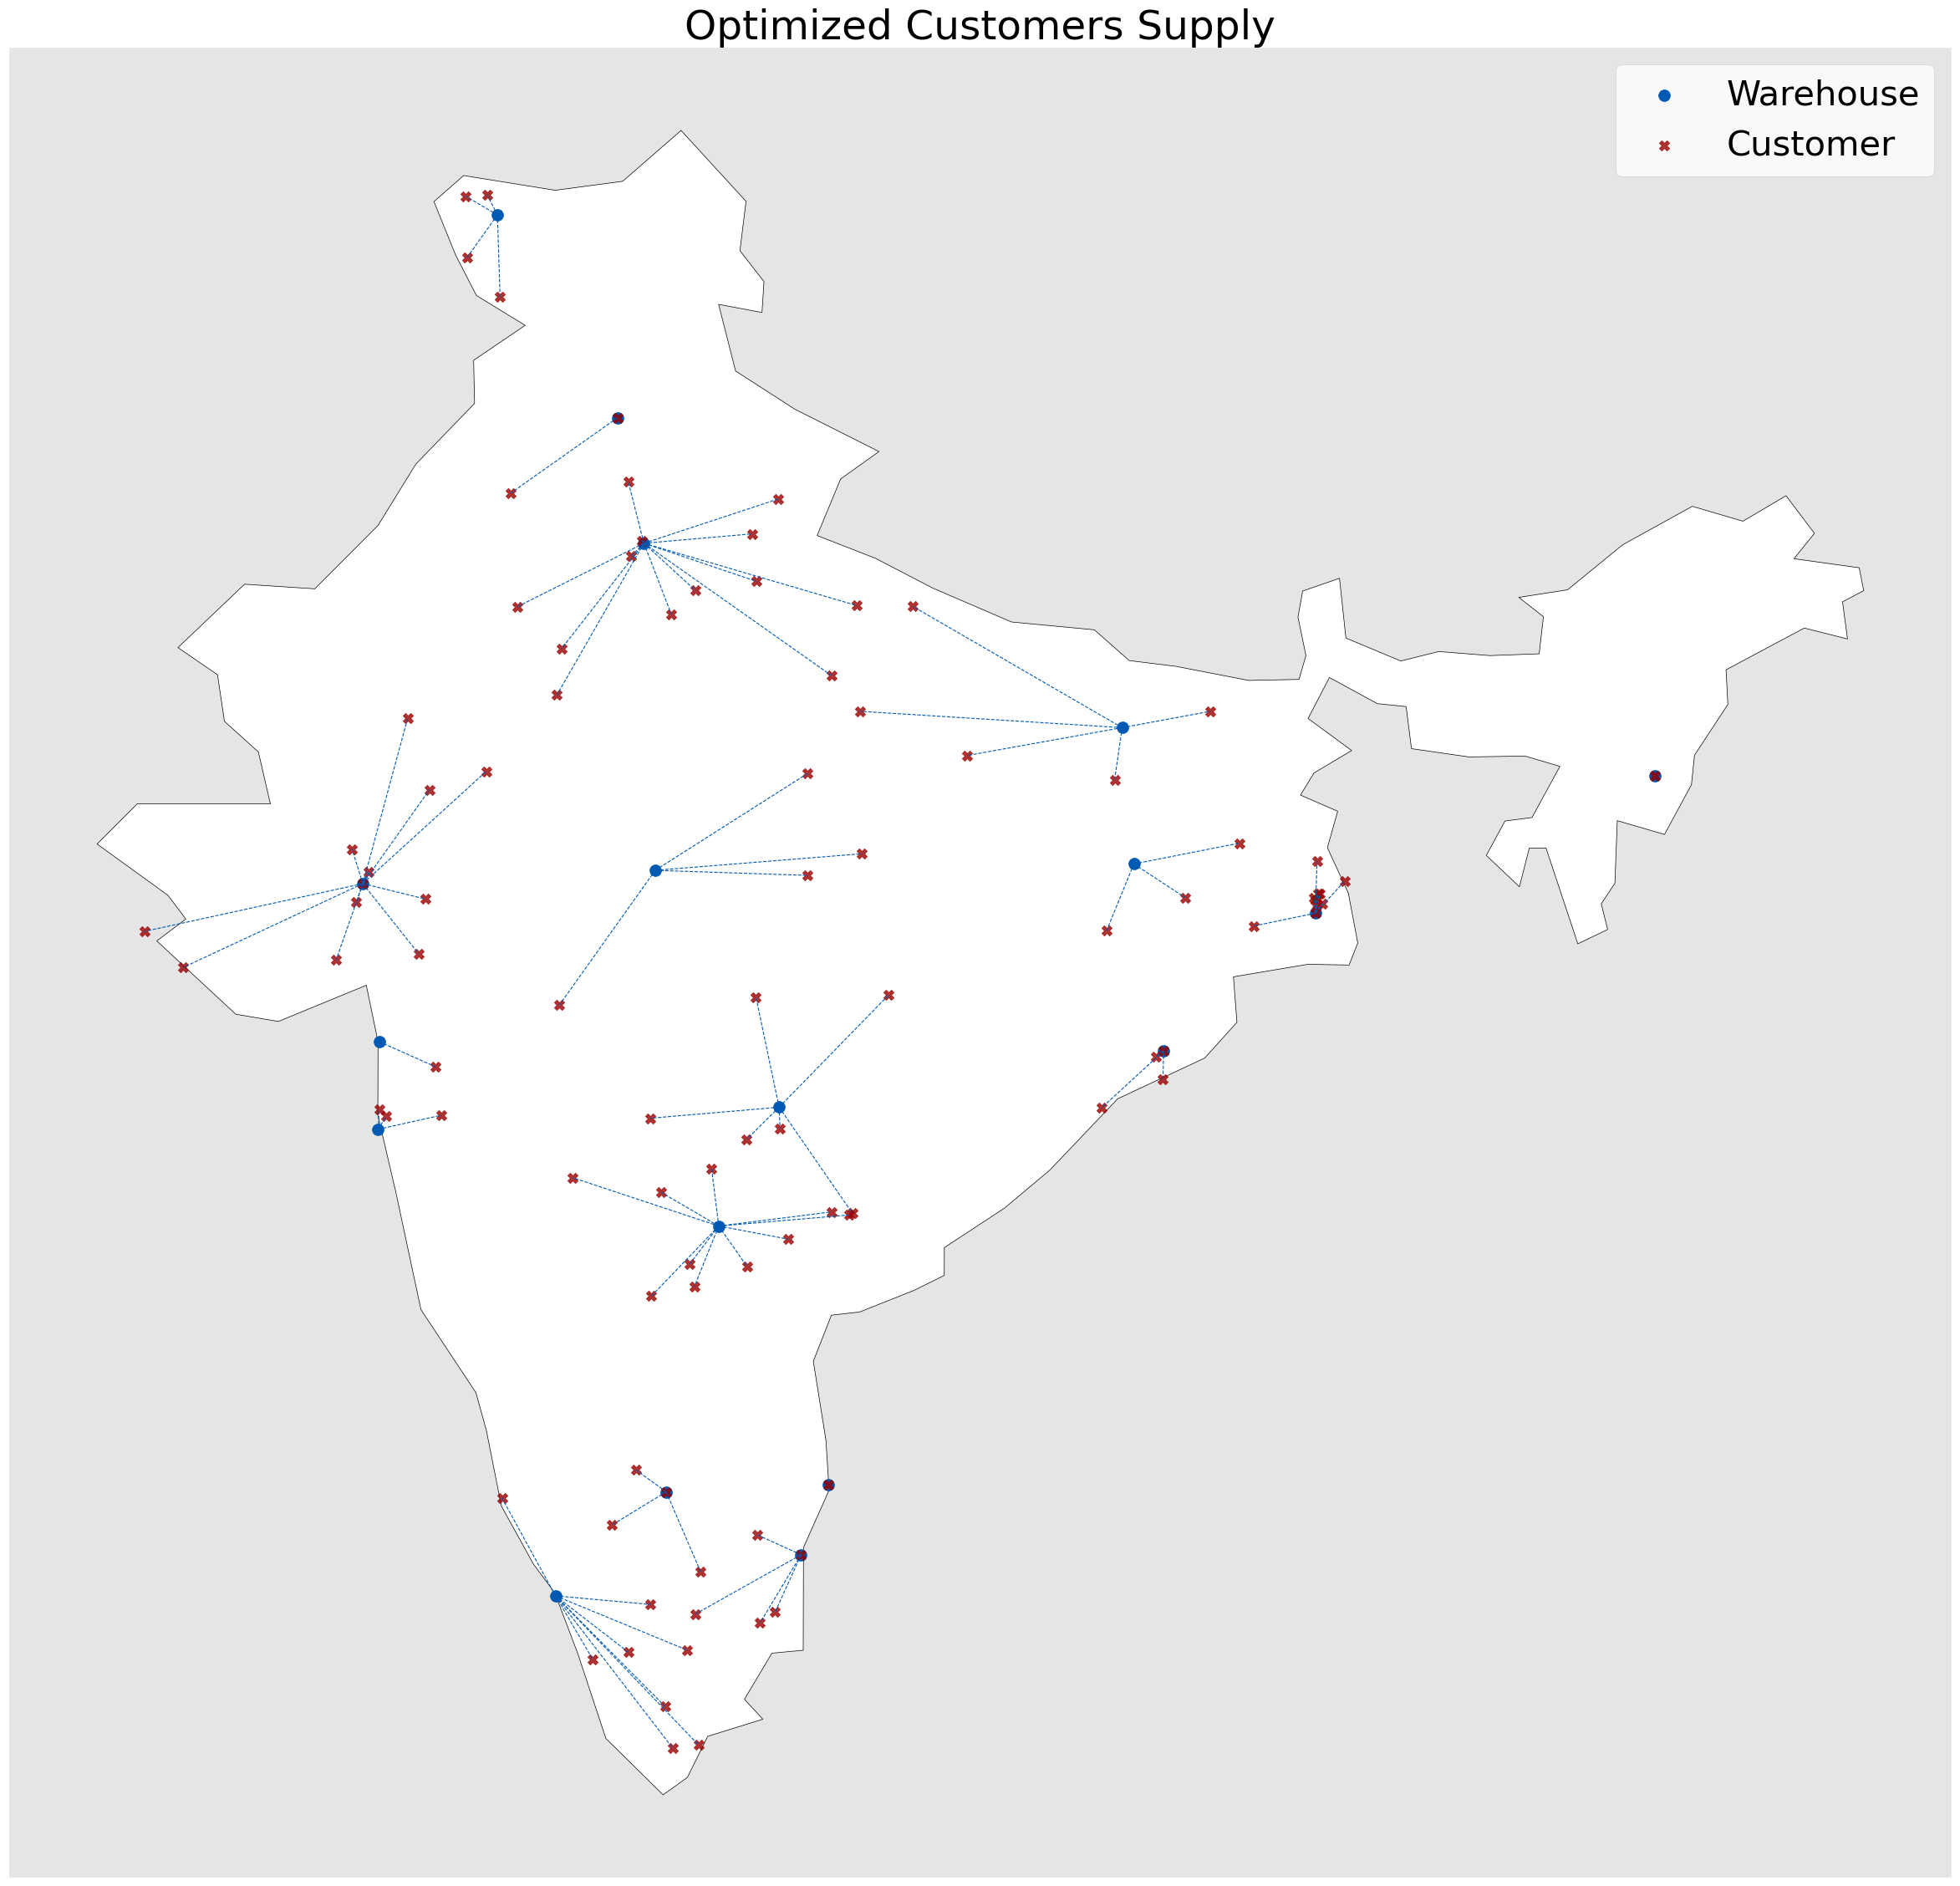

In [62]:
def get_linked_customers(input_warehouse):
    '''
    Find customer ids that are served by the input warehouse.
    
    Args:
        - input_warehouse: string (example: <Warehouse 21>)
    Out:
        - List of customers ids connected to the warehouse
    '''
    # Initialize empty list
    linked_customers = []
    
    # Iterate through the xij decision variable
    for (k, v) in served_customer.items():
            
            # Filter the input warehouse and positive variable values
            if k[1]==input_warehouse and v.varValue>0:
                
                # Customer is served by the input warehouse
                linked_customers.append(k[0])

    return linked_customers


# Warehouses to establish
establish = facility_df.loc[facility_df.build_warehouse =='Yes']

# Plot the shape of India
ax = india.plot(color='white', edgecolor='black', figsize=(30, 30))

# Plot sites to establish
establish.\
    plot(ax=ax, marker='o', c='#0059b3', markersize=100, label='Warehouse')

# Plot customers
customer_df.\
    plot(ax=ax, marker='X', color='#990000', markersize=80, alpha=0.8, label='Customer')

# For each warehouse to build
for w in establish.warehouse_id:

    # Extract list of customers served by the warehouse
    linked_customers = get_linked_customers(w)

    # For each served customer
    for c in linked_customers:
    
        # Plot connection between warehouse and the served customer
        ax.plot(
         [establish.loc[establish.warehouse_id==w].lng, customer_df.loc[customer_df.customer_id==c].lng],
         [establish.loc[establish.warehouse_id==w].lat, customer_df.loc[customer_df.customer_id==c].lat],
         linewidth=0.8, linestyle='--', color='#0059b3')

# Add title
plt.title('Optimized Customers Supply', fontsize = 35)

# Add legend
plt.legend(facecolor='white', fontsize=30)

# Remove ticks from axis
plt.xticks([])
plt.yticks([])

# Show plot
plt.show()